# SpaceXAI compute model

A Monte Carlo estimate of the compute available to SpaceXAI — SpaceX's AI
segment (xAI + X, including Cursor) — at three snapshots: **end-2024**,
**end-2025**, and **mid-2026** (June 30), in H100-equivalents (H100e).

Nearly all of SpaceXAI's compute sits in two campuses — **Colossus 1**
(Memphis) and **Colossus 2** (Memphis/Southaven) — tracked with dated
capacity estimates in Epoch's
[AI Data Centers directory](https://epoch.ai/data/ai-data-centers/directory/colossus-2).
Following the approach of
[this gradient update](https://epoch.ai/gradient-updates/frontier-labs-dont-use-most-ai-compute),
the fleet is anchored directly on those estimates rather than on chip-fleet
accounting:

> `SpaceXAI H100e = Colossus capacity × accuracy + other compute − cloud sales`

1. **Colossus capacity** — Epoch's milestone estimates read at each
   snapshot date (section 1).
2. **Capacity accuracy** — a multiplicative factor for error in the
   timeline read (H100e conversion, satellite power reads).
3. **Other compute** — a small buffer for capacity outside the two
   campuses: cloud purchases plus minor owned sites.
4. **Cloud sales** (mid-2026 only) — Colossus capacity sold to Anthropic,
   Google, and Reflection AI from May–July 2026, netted out because the
   estimate targets SpaceXAI's own compute (section 5).

**Inputs are lognormal** unless noted, with each parameter's low/high
bounds read as the **90% credible interval**.

Units: Epoch's estimates score chips on dense 8-bit throughput (GB300 ≈
GB200 ≈ 2.5 H100e); conversions that credit the GB300 at 3.2–3.4× H100
read Colossus 2 ~25% larger.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import squigglepy as sq
from squigglepy.numbers import K, M

# Shared modules (lab_compute_utils, epoch_data) live at the repo root, one
# level up from notebooks/.
sys.path.insert(0, str(Path('..').resolve()))

N_SAMPLES = 5000
# squigglepy uses its own RNG; np.random.seed has no effect on sq sampling
sq.set_seed(42)

SLATE = "#24343B"       # SpaceXAI accent (near-black slate)
SLATE_DARK = "#0F1419"
RED = "#C25B4E"         # capacity sold to other labs


def fmt(x):
    """Format an H100e count for labels (millions or thousands)."""
    if x >= 1e6:
        return f"{x / 1e6:.2f}M"
    return f"{x / 1e3:.0f}k"


def summary(name, samples):
    """Print 5th / median / 95th and mean for a sample array.

    Values below 10 are treated as fractions and shown as decimals; larger
    values are H100e counts and shown in millions/thousands.
    """
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    f = (lambda x: f"{x:.3f}") if np.median(samples) < 10 else fmt
    print(f"{name}")
    print(f"  90% CI : {f(p[5])} – {f(p[95])}")
    print(f"  median : {f(p[50])}")
    print(f"  mean   : {f(np.mean(samples))}")
    return p

## Canonical parameters

The headline priors are loaded from `lab_model_params.csv` — the single
source of truth shared with the other lab notebooks and
`frontier_lab_compute_model.py`, whose `model_spacexai()` samples in the
same order as this notebook (the two match exactly under the shared seed).
The sheet's description column carries each prior's sourcing. Sensitivity
cells further down build local variants and don't touch it.

In [2]:
from lab_compute_utils import load_lab_params, lab_params_table

PARAMS = load_lab_params()["spacexai"]
lab_params_table("spacexai")

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,capacity_accuracy_2024,to,0.75,1.15,NaN,NaN,multiplier,Accuracy of the end-2024 Colossus anchor (~171...,7/14/26
1,capacity_accuracy_2025,to,0.90,1.10,NaN,NaN,multiplier,Accuracy of the end-2025 Colossus anchor (C1 ~...,7/14/26
2,capacity_accuracy_h1_2026,to,0.90,1.10,NaN,NaN,multiplier,Accuracy of the mid-2026 Colossus H100e reads ...,7/14/26
3,c2_next_phase_open_h1_2026,norm,0.00,0.15,0.0,1.0,share,Fraction of the next pending Colossus 2 phase ...,7/30/26
4,other_compute_2024,to,10000.00,60000.00,NaN,NaN,H100e,Compute outside the two Colossus campuses at e...,7/14/26
5,other_compute_2025,to,40000.00,150000.00,NaN,NaN,H100e,Compute outside the two Colossus campuses at e...,7/14/26
6,other_compute_h1_2026,to,40000.00,160000.00,NaN,NaN,H100e,Compute outside the two Colossus campuses at m...,7/14/26
7,google_ramp_share,to,0.15,0.50,NaN,1.0,share,Share of the Google deal (~110k GPUs = one of ...,7/14/26
8,anthropic_c2_spillover,uniform,0.00,95000.00,NaN,NaN,H100e,Possible Anthropic capacity on Colossus 2 beyo...,7/14/26
9,reflection_sold_h100e,uniform,0.00,45000.00,NaN,NaN,H100e,Reflection AI's Colossus 2 carve-out (immediat...,7/14/26


## 1. The Colossus anchor

Epoch's data-center timelines give dated milestone estimates of operational
H100e per site (printed below). The two sites read differently at a
snapshot date:

- **Colossus 1: interpolate.** It grew continuously (racks of H100s
  energizing week by week through 2024), so a date between milestones takes
  the linear interpolation.
- **Colossus 2: split into phases.** Capacity arrives in whole 110k–220k-GPU
  clusters, and the later milestones are Epoch *projections* rather than
  observations — so the level at the last milestone at or before the
  snapshot is firm, and the increment to the next milestone may be anywhere
  from not started to fully online (sampled in section 4).

In [3]:
from epoch_data import load_data_center_timelines

TIMELINES = load_data_center_timelines()

SNAPSHOTS = {
    "end-2024": pd.Timestamp("2024-12-31"),
    "end-2025": pd.Timestamp("2025-12-31"),
    "mid-2026": pd.Timestamp("2026-06-30"),
}


def site_milestones(site):
    """One site's dated milestone H100e estimates, sorted (milestones without
    an H100e estimate are skipped)."""
    rows = (TIMELINES[TIMELINES["Data center"] == site]
            .dropna(subset=["H100 equivalents"]).sort_values("Date"))
    return rows[["Date", "H100 equivalents"]].reset_index(drop=True)


def interp_h100e_at(site, when):
    """Operational H100e at a date, interpolated linearly between milestones
    (flat before the first and after the last). Used for Colossus 1."""
    rows = site_milestones(site)
    days = (rows["Date"] - rows["Date"].iloc[0]).dt.days.to_numpy(dtype=float)
    target = (when - rows["Date"].iloc[0]).days
    return float(np.interp(target, days, rows["H100 equivalents"].to_numpy(dtype=float)))


def phase_split_at(site, when):
    """Split a phase-built site's capacity at a date into (open, pending):
    the level at the last milestone at or before the date (0 if none), and
    the increment to the next milestone (0 if none). Used for Colossus 2."""
    rows = site_milestones(site)
    levels = rows["H100 equivalents"].to_numpy(dtype=float)
    before = (rows["Date"] <= when).to_numpy()
    open_level = float(levels[before][-1]) if before.any() else 0.0
    next_level = float(levels[~before][0]) if (~before).any() else open_level
    return open_level, max(next_level - open_level, 0.0)


print("Colossus 1 milestones:")
print(site_milestones("Colossus 1").to_string(index=False))
print("\nColossus 2 milestones:")
print(site_milestones("Colossus 2").to_string(index=False))

Colossus 1 milestones:
      Date  H100 equivalents
2024-04-24          0.000000
2024-08-11      25000.000000
2024-09-02     100000.000000
2025-02-17     200000.000000
2025-07-22     275795.856493
2025-09-17     209125.080684
2025-10-19     209125.080684
2025-11-07     275795.856493
2026-02-11     275795.856493
2026-05-06     275795.856493
2026-06-15     275795.856493

Colossus 2 milestones:
      Date  H100 equivalents
2025-02-28      0.000000e+00
2025-09-08      0.000000e+00
2025-10-19      2.779181e+05
2026-01-13      2.779181e+05
2026-04-06      5.558363e+05
2026-06-15      1.111673e+06
2027-02-25      1.824154e+06


The anchor at each snapshot: end-2024 catches Colossus 1 mid-ramp with C2
not yet started; end-2025 is the two observed first clusters, with no
pending phase (a January 2026 observation shows C2's second cluster not yet
open); mid-2026 has ~1.39M firm — Epoch's June 15 observation records the
400+ MW expansion online, two weeks before the snapshot — plus the ~712k
projected ~Feb 2027 phase pending, of which only a sliver can be open.
(Before Epoch's late-July data refresh the 400 MW phase was itself the
pending one, projected ~July 1 and sampled at median ~0.65.)

In [4]:
anchors = {}
for name, when in SNAPSHOTS.items():
    c1 = interp_h100e_at("Colossus 1", when)
    c2_open, c2_pending = phase_split_at("Colossus 2", when)
    anchors[name] = dict(c1=c1, c2_open=c2_open, c2_pending=c2_pending)

print(f"{'snapshot':>10}  {'Colossus 1':>11}  {'C2 open':>9}  {'C2 pending':>11}")
for name, a in anchors.items():
    print(f"{name:>10}  {fmt(a['c1']):>11}  {fmt(a['c2_open']):>9}  "
          f"{fmt(a['c2_pending']):>11}")

  snapshot   Colossus 1    C2 open   C2 pending
  end-2024         171k         0k           0k
  end-2025         276k       278k           0k
  mid-2026         276k      1.11M         712k


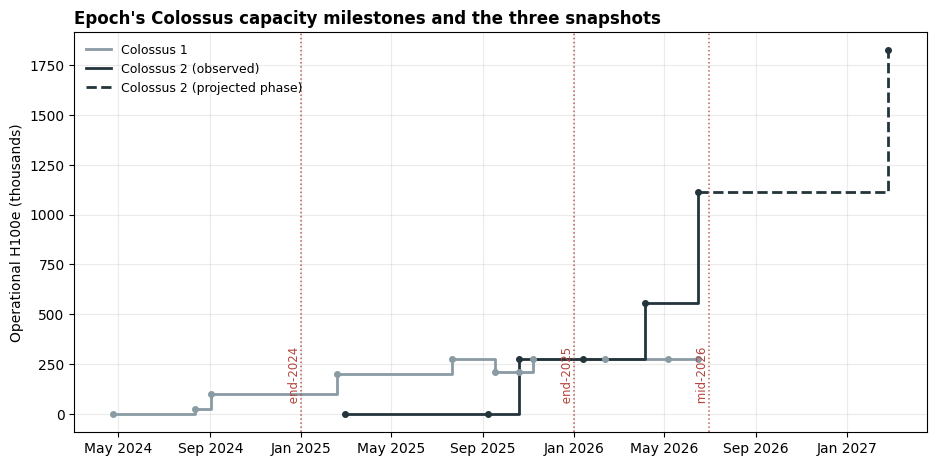

In [5]:
# Timeline chart: milestone step curves per site, the projected C2 phase
# dashed (it is an estimate, not an observation), snapshot dates as vertical
# lines.
c1_rows = site_milestones("Colossus 1")
c2_rows = site_milestones("Colossus 2")

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.step(c1_rows["Date"], c1_rows["H100 equivalents"] / 1e3, where="post",
        color="#8A9BA3", lw=2, label="Colossus 1")
# Colossus 2: solid through the last observed milestone (Jun 15, 2026 — the
# 400+ MW expansion online), then dashed to the projected ~Feb 2027 phase.
c2_observed = c2_rows[c2_rows["Date"] <= pd.Timestamp("2026-06-15")]
c2_projected = c2_rows[c2_rows["Date"] >= pd.Timestamp("2026-06-15")]
ax.step(c2_observed["Date"], c2_observed["H100 equivalents"] / 1e3,
        where="post", color=SLATE, lw=2, label="Colossus 2 (observed)")
ax.step(c2_projected["Date"], c2_projected["H100 equivalents"] / 1e3,
        where="post", color=SLATE, lw=2, ls="--",
        label="Colossus 2 (projected phase)")
ax.plot(c1_rows["Date"], c1_rows["H100 equivalents"] / 1e3, "o",
        color="#8A9BA3", ms=4)
ax.plot(c2_rows["Date"], c2_rows["H100 equivalents"] / 1e3, "o",
        color=SLATE, ms=4)

for name, when in SNAPSHOTS.items():
    ax.axvline(when, color="#B4443C", lw=1.1, ls=":", alpha=0.85)
    ax.text(when, ax.get_ylim()[1] * 0.02, f" {name}", rotation=90,
            va="bottom", ha="right", fontsize=8.5, color="#B4443C")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("Operational H100e (thousands)")
ax.set_title("Epoch's Colossus capacity milestones and the three snapshots",
             loc="left", weight="bold")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.grid(alpha=0.25)
plt.show()

## 2. End-2024: Colossus 1 mid-ramp

The anchor interpolates to ~171k H100e between the September 100k and
February 200k milestones. The **capacity accuracy** prior is widest here
(`to(0.75, 1.15)`) because the interpolation is doing real work: xAI
announced the doubling as complete in December, while Epoch dates the 200k
milestone to February. **Other compute** is a thin buffer of rented
capacity (Grok-2-era Oracle H100s) plus the small Atlanta site.

In [6]:
accuracy_2024 = PARAMS["capacity_accuracy_2024"] @ N_SAMPLES
colossus_2024 = (anchors["end-2024"]["c1"] + anchors["end-2024"]["c2_open"]) * accuracy_2024
other_2024 = PARAMS["other_compute_2024"] @ N_SAMPLES
spacexai_2024 = colossus_2024 + other_2024

summary("Capacity accuracy (end-2024)", accuracy_2024)
summary("Colossus operational (end-2024)", colossus_2024)
summary("Other sites + cloud purchases (end-2024)", other_2024)
summary("SpaceXAI compute, end-2024", spacexai_2024);

Capacity accuracy (end-2024)
  90% CI : 0.746 – 1.146
  median : 0.928
  mean   : 0.934
Colossus operational (end-2024)
  90% CI : 128k – 196k
  median : 159k
  mean   : 160k
Other sites + cloud purchases (end-2024)
  90% CI : 10k – 61k
  median : 24k
  mean   : 29k
SpaceXAI compute, end-2024
  90% CI : 150k – 235k
  median : 186k
  mean   : 189k


## 3. End-2025: two observed clusters

The firmest snapshot: both operating clusters are pinned by S-1
disclosures, so the accuracy prior narrows to `to(0.9, 1.1)`. **Other
compute** is anchored by the S-1's expense disclosures, which bound the
residual public-cloud run rate at roughly $1–2B/yr at end-2025 — ~30–90k
H100e at H100-class rental prices — plus minor owned sites.

In [7]:
# The implied H100e from the S-1 cloud-spend bounds, at H100-class rental
# prices — a sanity check on the buffer prior, not an input.
for spend_b in (1.0, 1.5, 2.5):
    lo, hi = spend_b * 1e9 / (3.5 * 8760), spend_b * 1e9 / (2.5 * 8760)
    print(f"${spend_b:.1f}B/yr of cloud at $2.5–3.5/H100e-hr ≈ "
          f"{fmt(lo)}–{fmt(hi)} H100e")

$1.0B/yr of cloud at $2.5–3.5/H100e-hr ≈ 33k–46k H100e
$1.5B/yr of cloud at $2.5–3.5/H100e-hr ≈ 49k–68k H100e
$2.5B/yr of cloud at $2.5–3.5/H100e-hr ≈ 82k–114k H100e


In [8]:
accuracy_2025 = PARAMS["capacity_accuracy_2025"] @ N_SAMPLES
colossus_2025 = (anchors["end-2025"]["c1"] + anchors["end-2025"]["c2_open"]) * accuracy_2025
other_2025 = PARAMS["other_compute_2025"] @ N_SAMPLES
spacexai_2025 = colossus_2025 + other_2025

summary("Capacity accuracy (end-2025)", accuracy_2025)
summary("Colossus operational (end-2025)", colossus_2025)
summary("Other sites + cloud purchases (end-2025)", other_2025)
summary("SpaceXAI compute, end-2025", spacexai_2025);

Capacity accuracy (end-2025)
  90% CI : 0.901 – 1.104
  median : 0.993
  mean   : 0.996
Colossus operational (end-2025)
  90% CI : 499k – 611k
  median : 550k
  mean   : 552k
Other sites + cloud purchases (end-2025)
  90% CI : 41k – 153k
  median : 79k
  mean   : 86k
SpaceXAI compute, end-2025
  90% CI : 564k – 726k
  median : 633k
  mean   : 637k


## 4. Mid-2026: the fleet, and which Colossus 2 phases are open

By June 30, 2026, everything through the 400+ MW expansion is firm: Epoch's
June 15 observation records that phase online, so Colossus reads ~1.39M
H100e observed (C1 ~276k + C2 ~1.11M) two weeks before the snapshot. (In
Epoch's earlier data this expansion was itself a ~July 1 *projection*, and
the model sampled it at median ~0.65 — its observed arrival is what moved
the mid-2026 estimate up from ~850k to ~1.1M.)

The **pending phase** is now the next projected expansion — ~712k H100e
dated ~Feb 25, 2027. Fifteen days into a ~255-day buildout only a sliver can
be energized, so the model samples the **fraction open by June 30** as a
normal with 90% CI 0–0.15, clipped at 0: median ~7%. The accuracy prior
stays at the measurement-only `to(0.9, 1.1)` — the timing risk lives in the
phase fraction.

In [9]:
accuracy_h1_2026 = PARAMS["capacity_accuracy_h1_2026"] @ N_SAMPLES
phase_open = PARAMS["c2_next_phase_open_h1_2026"] @ N_SAMPLES

a26 = anchors["mid-2026"]
c2_h1_2026 = a26["c2_open"] + a26["c2_pending"] * phase_open
colossus_h1_2026 = (a26["c1"] + c2_h1_2026) * accuracy_h1_2026
other_h1_2026 = PARAMS["other_compute_h1_2026"] @ N_SAMPLES
fleet_h1_2026 = colossus_h1_2026 + other_h1_2026

p = summary("Share of the next C2 phase open", phase_open)
print(f"  P(nothing open) = {np.mean(phase_open == 0.0):.0%}\n")
summary("Colossus 2 capacity (mid-2026)", c2_h1_2026)
summary("Colossus operational (mid-2026)", colossus_h1_2026)
summary("Total SpaceX fleet (mid-2026)", fleet_h1_2026);

Share of the next C2 phase open
  90% CI : 0.000 – 0.152
  median : 0.076
  mean   : 0.076
  P(nothing open) = 5%

Colossus 2 capacity (mid-2026)
  90% CI : 1.11M – 1.22M
  median : 1.17M
  mean   : 1.17M
Colossus operational (mid-2026)
  90% CI : 1.29M – 1.60M
  median : 1.44M
  mean   : 1.44M
Total SpaceX fleet (mid-2026)
  90% CI : 1.37M – 1.70M
  median : 1.52M
  mean   : 1.53M


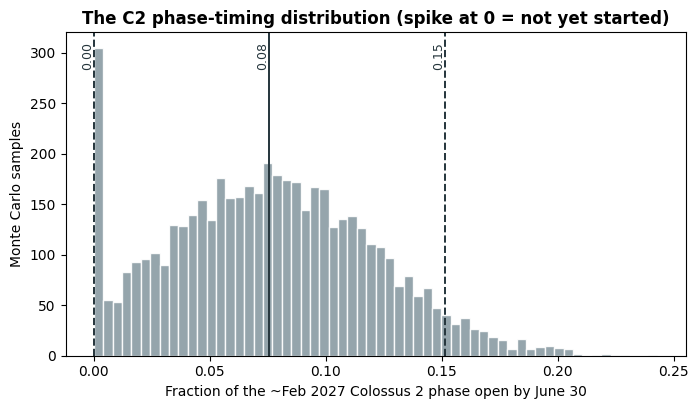

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(phase_open, bins=60, color="#8A9BA3", alpha=0.9, edgecolor="white")
for q, style in [(5, "--"), (50, "-"), (95, "--")]:
    ax.axvline(p[q], color=SLATE, ls=style, lw=1.4)
    ax.text(p[q], ax.get_ylim()[1] * 0.97, f"{p[q]:.2f}", rotation=90,
            va="top", ha="right", fontsize=9, color=SLATE)
ax.set_xlabel("Fraction of the ~Feb 2027 Colossus 2 phase open by June 30")
ax.set_ylabel("Monte Carlo samples")
ax.set_title("The C2 phase-timing distribution (spike at 0 = not yet started)",
             weight="bold")
plt.show()

## 5. Mid-2026: netting out the cloud sales

Three deals carve capacity out of the fleet from May–July 2026 and are
subtracted (no subtraction applies to the earlier snapshots):

- **Anthropic**: all of Colossus 1, so the subtraction reuses the C1 anchor
  times the same accuracy draw — plus a uniform 0–95k H100e of possible
  spillover into Colossus 2 (the S-1 places the capacity "across COLOSSUS
  and COLOSSUS II"; alternatively the deal's implied rate premium is just
  price).
- **Google**: one of Colossus 2's two ~110k-GPU clusters (~278k H100e),
  ramping through September — the sampled June-30 ramp share is
  `to(0.15, 0.5)`.
- **Reflection AI**: a small GB300 carve-out (~38–45k H100e) billing from
  July 1, the day after the snapshot — uniform 0–45k.

**Cursor stays in**: the S-1 treats its compute agreement as an internal
allocation, not a sale.

In [11]:
anthropic_spillover = PARAMS["anthropic_c2_spillover"] @ N_SAMPLES
anthropic_sold = a26["c1"] * accuracy_h1_2026 + anthropic_spillover

# The Google deal is one C2 cluster; size it off the first-cluster milestone
# (the end-2025 open level) and apply the sampled June-30 ramp share.
c2_first_cluster, _ = phase_split_at("Colossus 2", SNAPSHOTS["end-2025"])
google_ramp = PARAMS["google_ramp_share"] @ N_SAMPLES
google_sold = c2_first_cluster * accuracy_h1_2026 * google_ramp

reflection_sold = PARAMS["reflection_sold_h100e"] @ N_SAMPLES

spacexai_h1_2026 = fleet_h1_2026 - anthropic_sold - google_sold - reflection_sold

summary("Sold to Anthropic (all of C1 + spillover)", anthropic_sold)
summary("Sold to Google (one C2 cluster, ramping)", google_sold)
summary("Sold to Reflection AI", reflection_sold)
summary("SpaceXAI compute, mid-2026", spacexai_h1_2026);

Sold to Anthropic (all of C1 + spillover)
  90% CI : 272k – 375k
  median : 324k
  mean   : 323k
Sold to Google (one C2 cluster, ramping)
  90% CI : 41k – 137k
  median : 75k
  mean   : 81k
Sold to Reflection AI
  90% CI : 2k – 43k
  median : 23k
  mean   : 22k
SpaceXAI compute, mid-2026
  90% CI : 955k – 1.25M
  median : 1.10M
  mean   : 1.10M


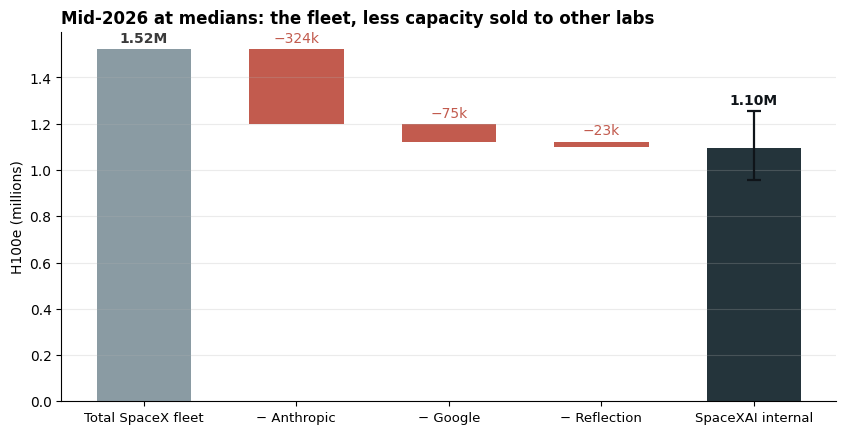

In [12]:
# Waterfall: the fleet at medians, less each sale, down to the internal
# estimate (which carries the full 90% CI).
wf_fleet = np.median(fleet_h1_2026)
wf_sales = [("Anthropic", np.median(anthropic_sold)),
            ("Google", np.median(google_sold)),
            ("Reflection", np.median(reflection_sold))]
wf_lo, wf_med, wf_hi = np.percentile(spacexai_h1_2026, [5, 50, 95])

fig, ax = plt.subplots(figsize=(10, 4.8))
labels = ["Total SpaceX fleet"] + [f"− {n}" for n, _ in wf_sales] + ["SpaceXAI internal"]
running = wf_fleet
ax.bar(0, wf_fleet / 1e6, width=0.62, color="#8A9BA3")
ax.text(0, wf_fleet / 1e6 + 0.03, fmt(wf_fleet), ha="center", fontsize=10,
        fontweight="bold", color="#3a3a3a")
for i, (name, sold) in enumerate(wf_sales, start=1):
    ax.bar(i, sold / 1e6, bottom=(running - sold) / 1e6, width=0.62, color=RED)
    ax.text(i, running / 1e6 + 0.03, f"−{fmt(sold)}", ha="center", fontsize=10,
            color=RED)
    running -= sold
ax.bar(len(labels) - 1, wf_med / 1e6, width=0.62, color=SLATE)
ax.errorbar(len(labels) - 1, wf_med / 1e6,
            yerr=[[(wf_med - wf_lo) / 1e6], [(wf_hi - wf_med) / 1e6]],
            fmt="none", ecolor=SLATE_DARK, elinewidth=1.6, capsize=5,
            capthick=1.6, zorder=3)
ax.text(len(labels) - 1, wf_hi / 1e6 + 0.03, fmt(wf_med), ha="center",
        fontsize=10, fontweight="bold", color=SLATE_DARK)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("H100e (millions)")
ax.set_title("Mid-2026 at medians: the fleet, less capacity sold to other labs",
             loc="left", weight="bold")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(alpha=0.25, axis="y")
plt.show()

The medians in the waterfall don't difference exactly to the internal
median (medians aren't additive), but the gap is small. The internal figure
measures *access* rather than use: the sale contracts carry 90–180-day
cancellation windows and claw-back rights.

## 6. Results across the three snapshots

The mid-2026 row also shows the gross fleet (before cloud sales) for
comparison.

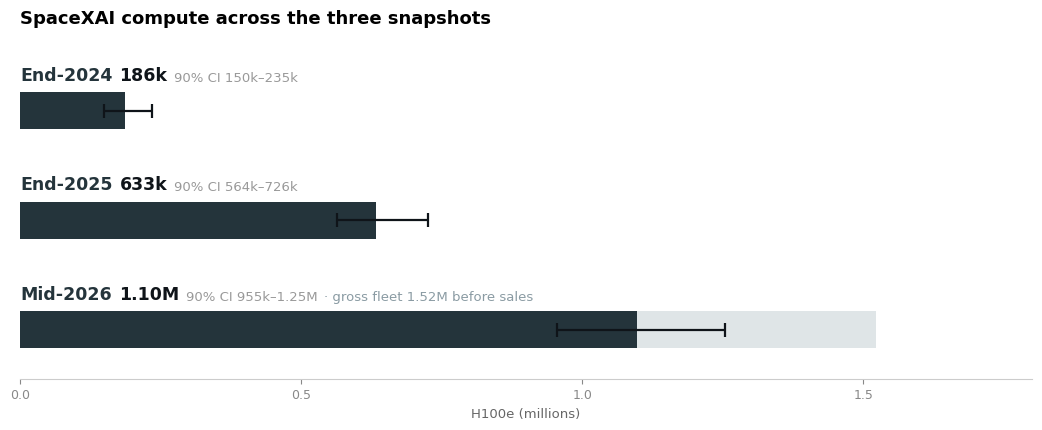

In [13]:
def label_spans(ax, x, y, spans, pad_px=7):
    """Draw text spans left-to-right starting at data-x, each with its own style."""
    for txt, kw in spans:
        t = ax.text(x, y, txt, ha="left", va="bottom", **kw)
        ax.figure.canvas.draw()
        x = ax.transData.inverted().transform(
            (t.get_window_extent().x1 + pad_px, 0))[0]


results = [
    ("End-2024", spacexai_2024, None),
    ("End-2025", spacexai_2025, None),
    ("Mid-2026", spacexai_h1_2026, fleet_h1_2026),
]

fig, ax = plt.subplots(figsize=(11, 4.6))
fig.subplots_adjust(left=0.05, right=0.97, top=0.86, bottom=0.13)
ax.set_xlim(0, 1.8)
ax.set_ylim(-0.45, len(results) - 1 + 0.62)

bar_h = 0.34
for i, (name, samples, gross) in enumerate(results):
    y = len(results) - 1 - i
    lo, med, hi = np.percentile(samples, [5, 50, 95])
    if gross is not None:
        # ghost bar: the gross fleet before netting out cloud sales
        glo, gmed, ghi = np.percentile(gross, [5, 50, 95])
        ax.barh(y, gmed / 1e6, height=bar_h, color="#DFE5E7", zorder=1)
    ax.barh(y, med / 1e6, height=bar_h, color=SLATE, zorder=2)
    ax.errorbar(med / 1e6, y, xerr=[[(med - lo) / 1e6], [(hi - med) / 1e6]],
                fmt="none", ecolor=SLATE_DARK, elinewidth=1.6, capsize=5,
                capthick=1.6, zorder=3)
    spans = [
        (name, dict(fontsize=12.5, fontweight="bold", color=SLATE)),
        (fmt(med), dict(fontsize=12.5, fontweight="bold", color=SLATE_DARK)),
        (f"90% CI {fmt(lo)}–{fmt(hi)}", dict(fontsize=9.5, color="#999999")),
    ]
    if gross is not None:
        spans.append((f"· gross fleet {fmt(gmed)} before sales",
                      dict(fontsize=9.5, color="#8A9BA3")))
    label_spans(ax, 0, y + 0.24, spans)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.set_yticks([])
ax.set_xticks([0, 0.5, 1, 1.5])
ax.tick_params(axis="x", colors="#888888", labelsize=9)
ax.set_xlabel("H100e (millions)", color="#666666", fontsize=9.5)
ax.set_title("SpaceXAI compute across the three snapshots",
             loc="left", fontsize=13, weight="bold", pad=14)
plt.show()

## Sensitivity check: the Colossus 2 phase timing

The phase-open fraction is **fixed** at values from 0 (none of the ~Feb 2027
phase energized yet) to 1 (the whole thing implausibly online), reusing
every other draw. With the 400+ MW expansion now observed rather than
sampled, this knob moves the estimate far less than it used to — the
baseline sits near the bottom of the sweep.

fraction open       5th    median      95th
         0.00      912k     1.04M     1.19M
         0.07      961k     1.10M     1.25M  <- baseline median
         0.25     1.08M     1.22M     1.38M
         0.50     1.24M     1.40M     1.57M
         0.75     1.40M     1.58M     1.77M
         1.00     1.57M     1.75M     1.96M


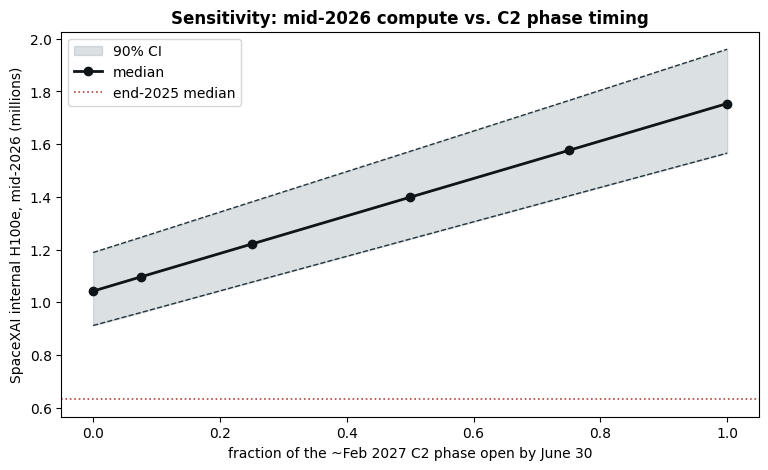

In [14]:
phase_scenarios = [0.0, 0.075, 0.25, 0.5, 0.75, 1.0]

rows = []
for f in phase_scenarios:
    c2 = a26["c2_open"] + a26["c2_pending"] * f
    internal = ((a26["c1"] + c2) * accuracy_h1_2026 + other_h1_2026
                - anthropic_sold - google_sold - reflection_sold)
    pc = sq.get_percentiles(internal, percentiles=[5, 50, 95])
    rows.append((f, pc[5], pc[50], pc[95]))

print(f"{'fraction open':>13}  {'5th':>8}  {'median':>8}  {'95th':>8}")
for f, lo, med, hi in rows:
    marker = "  <- baseline median" if f == 0.075 else ""
    print(f"{f:>13.2f}  {fmt(lo):>8}  {fmt(med):>8}  {fmt(hi):>8}{marker}")

fracs = [r[0] for r in rows]
los = np.array([r[1] for r in rows]) / 1e6
meds = np.array([r[2] for r in rows]) / 1e6
his = np.array([r[3] for r in rows]) / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(fracs, los, his, color="#8A9BA3", alpha=0.30, label="90% CI")
ax.plot(fracs, his, "--", color=SLATE, lw=1)
ax.plot(fracs, los, "--", color=SLATE, lw=1)
ax.plot(fracs, meds, "o-", color=SLATE_DARK, lw=2, label="median")
ax.axhline(np.median(spacexai_2025) / 1e6, color="#B4443C", lw=1.2, ls=":",
           label="end-2025 median")
ax.set_xlabel("fraction of the ~Feb 2027 C2 phase open by June 30")
ax.set_ylabel("SpaceXAI internal H100e, mid-2026 (millions)")
ax.set_title("Sensitivity: mid-2026 compute vs. C2 phase timing", weight="bold")
ax.legend()
plt.show()

## Sensitivity check: what moves the mid-2026 estimate most

A one-at-a-time sweep: each sampled input is pinned to its own 5th and then
95th percentile while everything else keeps its full distribution, and the
bar spans the resulting pair of medians.

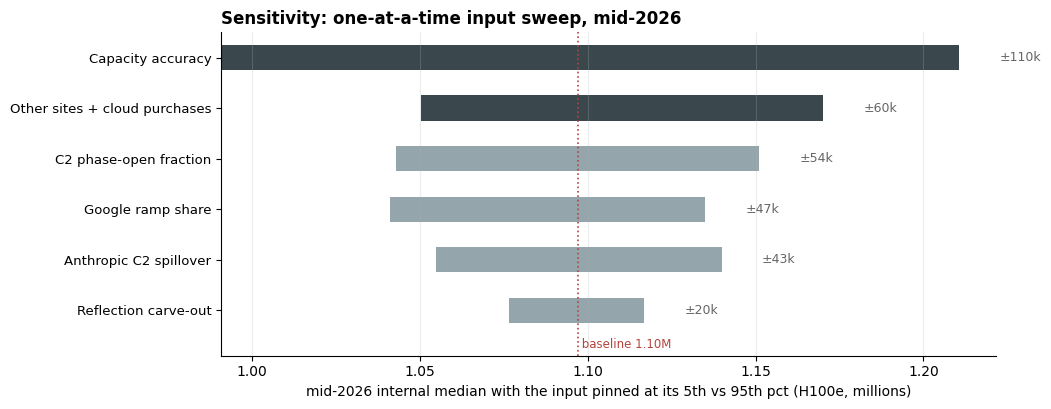

In [15]:
def internal_with(acc=None, phase=None, other=None, spill=None, ramp=None,
                  refl=None):
    """Recompute the mid-2026 internal estimate with some inputs pinned to
    scalars (None keeps the sampled array)."""
    acc = accuracy_h1_2026 if acc is None else acc
    phase = phase_open if phase is None else phase
    other = other_h1_2026 if other is None else other
    spill = anthropic_spillover if spill is None else spill
    ramp = google_ramp if ramp is None else ramp
    refl = reflection_sold if refl is None else refl
    c2 = a26["c2_open"] + a26["c2_pending"] * phase
    fleet = (a26["c1"] + c2) * acc + other
    sold = (a26["c1"] * acc + spill) + c2_first_cluster * acc * ramp + refl
    return fleet - sold


tornado_inputs = [
    ("C2 phase-open fraction", "phase", phase_open),
    ("Capacity accuracy", "acc", accuracy_h1_2026),
    ("Other sites + cloud purchases", "other", other_h1_2026),
    ("Anthropic C2 spillover", "spill", anthropic_spillover),
    ("Google ramp share", "ramp", google_ramp),
    ("Reflection carve-out", "refl", reflection_sold),
]

baseline_med = np.median(spacexai_h1_2026)
tornado = []
for label, kw, samples in tornado_inputs:
    lo_med = np.median(internal_with(**{kw: np.percentile(samples, 5)}))
    hi_med = np.median(internal_with(**{kw: np.percentile(samples, 95)}))
    tornado.append((label, lo_med, hi_med))
tornado.sort(key=lambda r: abs(r[2] - r[1]), reverse=True)

fig, ax = plt.subplots(figsize=(10, 4.2))
for i, (label, lo_med, hi_med) in enumerate(tornado):
    y = len(tornado) - 1 - i
    left, width = min(lo_med, hi_med), abs(hi_med - lo_med)
    ax.barh(y, width / 1e6, left=left / 1e6, height=0.5,
            color=SLATE if i < 2 else "#8A9BA3", alpha=0.9)
    ax.text(max(lo_med, hi_med) / 1e6 + 0.012, y, f"±{fmt(width / 2)}",
            va="center", fontsize=9, color="#666666")
ax.axvline(baseline_med / 1e6, color="#B4443C", lw=1.2, ls=":")
ax.set_ylim(-0.9, len(tornado) - 0.5)
ax.text(baseline_med / 1e6, -0.8, f" baseline {fmt(baseline_med)}",
        fontsize=8.5, color="#B4443C", va="bottom")
ax.set_yticks(range(len(tornado)))
ax.set_yticklabels([r[0] for r in reversed(tornado)], fontsize=9.5)
ax.set_xlabel("mid-2026 internal median with the input pinned at its 5th vs 95th pct (H100e, millions)")
ax.set_title("Sensitivity: one-at-a-time input sweep, mid-2026",
             loc="left", weight="bold")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(alpha=0.25, axis="x")
plt.show()

## Bottom line

- **End-2024: ~185k H100e** (90% CI ~150–235k).
- **End-2025: ~630k H100e** (90% CI ~565–725k).
- **Mid-2026: ~1.10M H100e internal** (90% CI ~955k–1.25M), against a gross
  fleet of ~1.52M before the capacity sold to Anthropic, Google, and
  Reflection. (Up from ~850k before Epoch's late-July data refresh, which
  records the 400+ MW C2 expansion as observed online June 15 rather than a
  ~July 1 projection sampled at ~0.65.)